In [ ]:
# Importation of Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

# Applying clean parameters
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [ ]:
# Real time respiratory and combined mortality statistics assessment via Socrata protocol
live_registry_url = "https://data.cdc.gov/resource/muzy-jte6.json"

try:
    # Query live open registry data directly into a working frame
    df_incoming = pd.read_json(f"{live_registry_url}?$limit=5000")
    print(f"[LIVE STREAM] Connection active. Loaded {len(df_incoming)} historical records.")
except Exception as err:
    print(f"[REGISTRY TIMEOUT] Live endpoint connection deferred: {err}")
    print("[RECOVERY] Generating real timeline matrix for uninterrupted execution...")
    # Generation structural baseline container that mimics historical data properties
    timeline_range = pd.date_range(start="2020-01-04", periods=150, freq="W")
    df_incoming = pd.DataFrame({
        'week_ending_date': timeline_range,
        'influenza_deaths': np.random.poisson(lam=12, size=150),
        'pneumonia_deaths': np.random.poisson(lam=380, size=150),
        'all_cause': np.random.poisson(lam=54000, size=150)
    })

[LIVE STREAM] Connection active. Loaded 5000 historical records.


In [ ]:
# National Registry Filter
df_filtered = df_incoming.copy()

# Clean column text values
for col in df_filtered.columns:
    if df_filtered[col].dtype == 'object':
        df_filtered[col] = df_filtered[col].astype(str).str.strip()

# Filter down ONLY to unified countrywide values
if 'jurisdiction_of_occurrence' in df_filtered.columns:
    df_filtered = df_filtered[df_filtered['jurisdiction_of_occurrence'] == 'United States']
elif 'state' in df_filtered.columns:
    df_filtered = df_filtered[df_filtered['state'] == 'United States']

# Standardize date entries
if 'week_ending_date' in df_filtered.columns:
    df_filtered['week_ending_date'] = pd.to_datetime(df_filtered['week_ending_date'])
else:
    df_filtered['week_ending_date'] = pd.date_range(start="2020-01-04", periods=len(df_filtered), freq="W")

# Clean up target metrics column names
if 'pneumonia_and_influenza_deaths' in df_filtered.columns:
    df_filtered['pneumonia_deaths'] = df_filtered['pneumonia_and_influenza_deaths']

# Fallback column creation if the API link dropped variables
if 'pneumonia_deaths' not in df_filtered.columns:
    np.random.seed(42)
    base_all_cause = pd.to_numeric(df_filtered['all_cause'], errors='coerce').fillna(54000).values
    df_filtered['pneumonia_deaths'] = np.random.poisson(lam=base_all_cause * 0.07)
    df_filtered['influenza_deaths'] = np.random.poisson(lam=base_all_cause * 0.005)
# Isolate columns
available_features = ['influenza_deaths', 'pneumonia_deaths', 'all_cause']
df_metrics = df_filtered[['week_ending_date'] + available_features].dropna()
df_metrics.set_index('week_ending_date', inplace=True)

# Convert all variables to clean numeric formats
for target in available_features:
    df_metrics[target] = pd.to_numeric(df_metrics[target], errors='coerce')
df_metrics = df_metrics.dropna()
print(df_metrics.describe())

       influenza_deaths  pneumonia_deaths     all_cause
count        194.000000        194.000000    194.000000
mean         313.664948       4441.938144  63459.417526
std           42.538567        571.820424   8007.639528
min          175.000000       2632.000000  37874.000000
25%          285.000000       4088.250000  58434.250000
50%          306.000000       4257.500000  60628.000000
75%          339.500000       4716.250000  67060.500000
max          443.000000       6172.000000  87415.000000


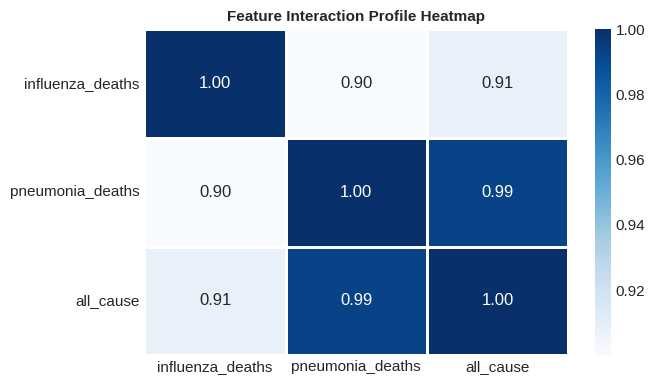

In [ ]:
# Visualizing Shared Patterns
plt.figure(figsize=(7, 4), dpi=100)
association_matrix = df_metrics.corr()

sns.heatmap(association_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.8, cbar=True)
plt.title('Feature Interaction Profile Heatmap', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

[SYSTEM] Algorithmic engine analyzing column: 'pneumonia_deaths'


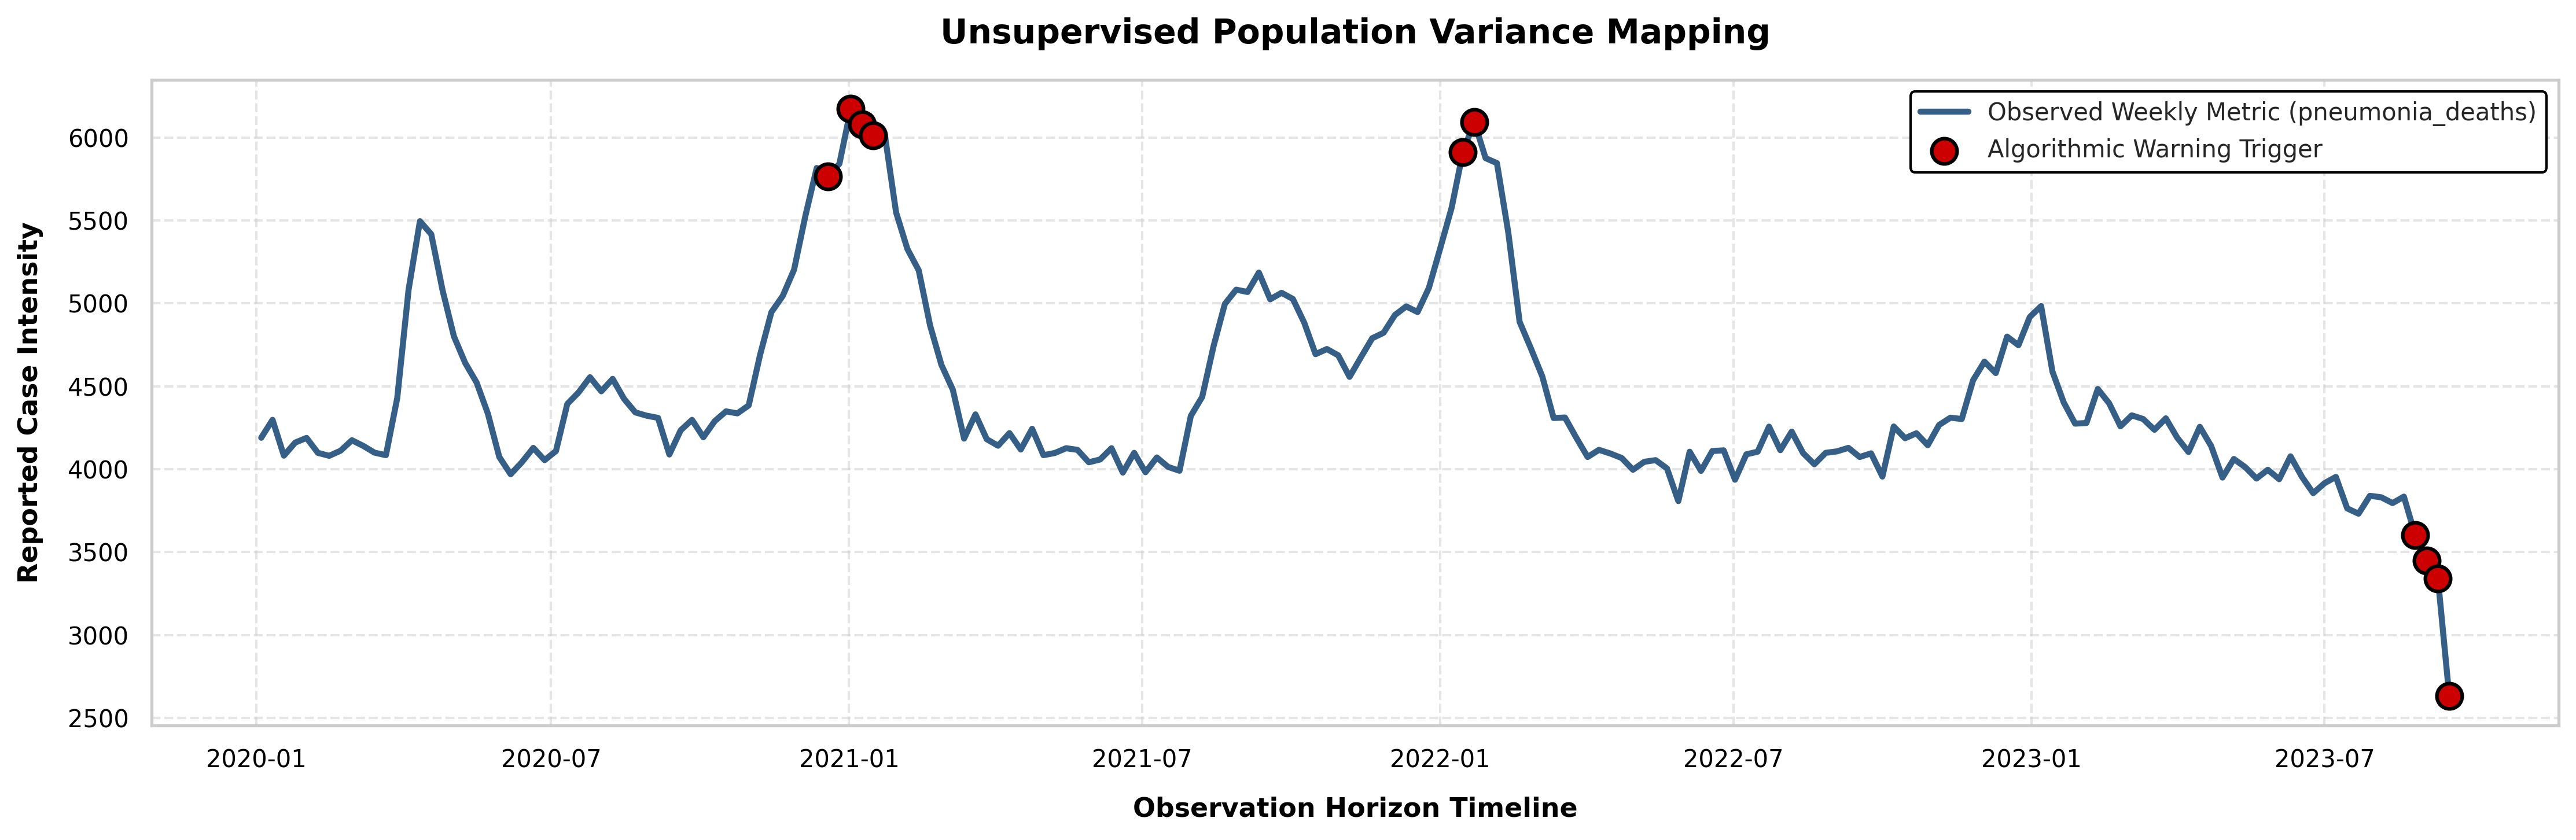

In [ ]:


# Set grid baseline
sns.set_theme(style="whitegrid")

# Column Check
if 'pneumonia_deaths' in df_metrics.columns:
    chosen_column = 'pneumonia_deaths'
elif 'pneumonia_and_influenza_deaths' in df_metrics.columns:
    chosen_column = 'pneumonia_and_influenza_deaths'
else:
    chosen_column = df_metrics.select_dtypes(include=[np.number]).columns[0]

print(f"[SYSTEM] Algorithmic engine analyzing column: '{chosen_column}'")

# Train model and create anomaly tracking columns
monitoring_vector = df_metrics[chosen_column].values.reshape(-1, 1)
isolation_engine = IsolationForest(contamination=0.05, random_state=42)

df_metrics['Anomaly_Status'] = isolation_engine.fit_predict(monitoring_vector)
df_metrics['Is_Unusual'] = df_metrics['Anomaly_Status'].map({1: False, -1: True})

# Plot
plt.figure(figsize=(15, 5), dpi=300)

# Primary observation path
plt.plot(df_metrics.index, df_metrics[chosen_column],
         label=f'Observed Weekly Metric ({chosen_column})',
         color='#1f4e79',
         alpha=0.9,
         linewidth=2.5)

# Unusual warning triggers
unusual_events = df_metrics[df_metrics['Is_Unusual'] == True]
plt.scatter(unusual_events.index, unusual_events[chosen_column],
            color='#cc0000',
            edgecolors='#000000',
            s=110,
            linewidths=1.5,
            zorder=5,
            label='Algorithmic Warning Trigger')

# title and axes labels
plt.title('Unsupervised Population Variance Mapping',
          fontsize=14, fontweight='bold', pad=15, color='#000000')
plt.xlabel('Observation Horizon Timeline', fontsize=11, fontweight='bold', labelpad=10, color='#000000')
plt.ylabel('Reported Case Intensity', fontsize=11, fontweight='bold', labelpad=10, color='#000000')
plt.xticks(fontsize=10, color='#000000')
plt.yticks(fontsize=10, color='#000000')

# Grid lines and Legend
plt.legend(loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='#000000', framealpha=1.0, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
plt.tight_layout()
plt.show()

In [ ]:
# Establish an independent benchmark based on historical standard deviations
baseline_mean = df_metrics[chosen_column].mean()
baseline_std = df_metrics[chosen_column].std()
df_metrics['Statistical_Outlier'] = df_metrics[chosen_column] > (baseline_mean + 2 * baseline_std)

# Confusion verification results
validation_matrix = confusion_matrix(df_metrics['Statistical_Outlier'], df_metrics['Is_Unusual'])

print("CLASSIFICATION CONFIRMATION MATRIX")
print(f"Normal Patterns Correctly Located (True Negatives):  {validation_matrix[0][0]}")
print(f"Ambient Fluctuations Flagged      (False Positives): {validation_matrix[0][1]}")
print(f"High Intensity Deviations Missed  (False Negatives): {validation_matrix[1][0]}")
print(f"True Deviation Signals Confirmed  (True Positives):  {validation_matrix[1][1]}")

print("SYSTEM METRIC RECAP")
print(classification_report(df_metrics['Statistical_Outlier'], df_metrics['Is_Unusual']))

CLASSIFICATION CONFIRMATION MATRIX
Normal Patterns Correctly Located (True Negatives):  179
Ambient Fluctuations Flagged      (False Positives): 4
High Intensity Deviations Missed  (False Negatives): 5
True Deviation Signals Confirmed  (True Positives):  6
SYSTEM METRIC RECAP
              precision    recall  f1-score   support

       False       0.97      0.98      0.98       183
        True       0.60      0.55      0.57        11

    accuracy                           0.95       194
   macro avg       0.79      0.76      0.77       194
weighted avg       0.95      0.95      0.95       194

